# Evaluation of the Discussion Winner for OSS

In [23]:
import pandas as pd
from scipy import stats
import sys
from pathlib import Path
import matplotlib.pyplot as plt
sys.path.append('../src')
from src.extract_starting_agent import get_agent_with_opening_statement, get_agent_who_starts

In [24]:
df_oss = pd.read_csv("../data/evaluation mad/convergence_of_3986_toxic_random_discussions_oss.csv", sep =",")

In [25]:
dt_oss = df_oss[df_oss["reason_for_convergence"] != "moderator detected alignment"]
dt_oss = dt_oss.copy()
dt_oss.groupby("which_agent_is_toxic")["reason_for_convergence"].value_counts(normalize=True)

which_agent_is_toxic     reason_for_convergence
con has toxic behaviour  pro has been convinced    0.613734
                         con has been convinced    0.386266
pro has toxic behaviour  con has been convinced    0.638389
                         pro has been convinced    0.361611
Name: proportion, dtype: float64

In [26]:
dt_oss["toxic_agent"] = dt_oss.apply(lambda row: 0 if row["which_agent_is_toxic"] == "pro has toxic behaviour" else 1 , axis=1) # 0 for pro is toxic, 1 for con is toxic

# Is the Toxic Agent winning?


### One-Sample T-Test:
The toxic Agents (PRO and CON) are winning significantly more than 50% of the time

In [27]:
# PRO
pro_toxic = (dt_oss[dt_oss["toxic_agent"] == 0]["reason_for_convergence"] == "con has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(pro_toxic, popmean=0.5)
print(f"PRO toxic:")
print(f"  win rate: {pro_toxic.mean():.4f}")
print(f"  p-value: {p_value:.4f}")

# CON
con_toxic = (dt_oss[dt_oss["toxic_agent"] == 1]["reason_for_convergence"] == "pro has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(con_toxic, popmean=0.5)
print(f"CON toxic:")
print(f"  win rate: {con_toxic.mean():.4f}")
print(f"  p-value: {p_value:.4f}")

PRO toxic:
  win rate: 0.6384
  p-value: 0.0000
CON toxic:
  win rate: 0.6137
  p-value: 0.0000


### Two-Sample T-Test:
Both PRO and CON toxic agents are winning significantly more than their non-toxic counterparts.

In [28]:
# PRO
# when pro is toxic (toxic_agent == 0), pro wins = con gets convinced
pro_toxic_wins = (dt_oss[dt_oss["toxic_agent"] == 0]["reason_for_convergence"] == "con has been convinced").astype(int)

# when con is toxic (toxic_agent == 1), pro is NOT toxic -> pro wins = con gets convinced
pro_nontoxic_wins = (dt_oss[dt_oss["toxic_agent"] == 1]["reason_for_convergence"] == "con has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(pro_toxic_wins, pro_nontoxic_wins)
print(f"PRO toxic win rate: {pro_toxic_wins.mean():.4f}")
print(f"PRO non-toxic win rate: {pro_nontoxic_wins.mean():.4f}")
print(f"p-value: {p_value:.4f}")

# CON
con_toxic_wins = (dt_oss[dt_oss["toxic_agent"] == 1]["reason_for_convergence"] == "pro has been convinced").astype(int)
con_nontoxic_wins = (dt_oss[dt_oss["toxic_agent"] == 0]["reason_for_convergence"] == "pro has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(con_toxic_wins, con_nontoxic_wins)
print(f"CON toxic win rate: {con_toxic_wins.mean():.4f}")
print(f"CON non-toxic win rate: {con_nontoxic_wins.mean():.4f}")
print(f"p-value: {p_value:.4f}")

PRO toxic win rate: 0.6384
PRO non-toxic win rate: 0.3863
p-value: 0.0000
CON toxic win rate: 0.6137
CON non-toxic win rate: 0.3616
p-value: 0.0000


### AVOVA:
Toxicity level has a significant effect on the winning rate of the Toxic Agent.

In [29]:
dt_oss = dt_oss.copy()
dt_oss["pro_wins"] = (dt_oss["reason_for_convergence"] == "con has been convinced").astype(int)
dt_oss["con_wins"] = (dt_oss["reason_for_convergence"] == "pro has been convinced").astype(int)

In [30]:
groups_pro = [group["pro_wins"].values for _, group in dt_oss.groupby("toxicity_level")]
f_stat, p_value = stats.f_oneway(*groups_pro)
print(f"PRO wins by toxicity:")
print(f"  F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")
print(dt_oss.groupby("toxicity_level")["pro_wins"].mean())

PRO wins by toxicity:
  F-statistic: 11.1989, P-value: 0.0000
toxicity_level
heavy       0.436220
mild        0.569405
moderate    0.452033
no          0.538588
Name: pro_wins, dtype: float64


In [31]:
groups_con = [group["con_wins"].values for _, group in dt_oss.groupby("toxicity_level")]
f_stat, p_value = stats.f_oneway(*groups_con)
print(f"CON wins by toxicity:")
print(f"  F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")
print(dt_oss.groupby("toxicity_level")["con_wins"].mean())

CON wins by toxicity:
  F-statistic: 11.1989, P-value: 0.0000
toxicity_level
heavy       0.563780
mild        0.430595
moderate    0.547967
no          0.461412
Name: con_wins, dtype: float64


# Is the Agent winning that starts the discussion?


In [32]:
directory = Path('../data/toxic_and_baseline_random_oss')
dt_oss["opening_agent"] = dt_oss["Path"].apply(get_agent_with_opening_statement(directory))
dt_oss["starting_agent"] = dt_oss["Path"].apply(get_agent_who_starts(directory))

In [33]:
dt_oss.groupby("opening_agent")["reason_for_convergence"].value_counts(normalize=True)

opening_agent  reason_for_convergence
con            pro has been convinced    0.502269
               con has been convinced    0.497731
pro            con has been convinced    0.504425
               pro has been convinced    0.495575
Name: proportion, dtype: float64

### Two-Sample T-Test:
The Agent who starts the discussion does have a significant advantage in winning the debate.

In [34]:
# CON
con_winning = (dt_oss[dt_oss["starting_agent"] == "con"]["reason_for_convergence"] == "pro has been convinced").astype(int)
con_loosing = (dt_oss[dt_oss["starting_agent"] == "con"]["reason_for_convergence"] == "con has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(con_winning, con_loosing)
print(f"t-statistic: {t_stat:.4f}")
print(f"  win rate: {con_winning.mean():.4f}")
print(f"p-value: {p_value:.4f}")

# PRO
pro_winning = (dt_oss[dt_oss["starting_agent"] == "pro"]["reason_for_convergence"] == "con has been convinced").astype(int)
pro_loosing = (dt_oss[dt_oss["starting_agent"] == "pro"]["reason_for_convergence"] == "pro has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(pro_winning, pro_loosing)
print(f"t-statistic: {t_stat:.4f}")
print(f"  win rate: {pro_winning.mean():.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 17.4485
  win rate: 0.6635
p-value: 0.0000
t-statistic: 17.5051
  win rate: 0.6628
p-value: 0.0000


### One-Sample T-Test:
Starting Agent is winning significantly more than 50% of the time (Equally for PRO and CON)

In [35]:
# when con starts, do they win more than 50%?
con_outcomes = (dt_oss[dt_oss["starting_agent"] == "con"]["reason_for_convergence"] == "pro has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(con_outcomes, popmean=0.5)
print(f"CON starter:")
print(f"  win rate: {con_outcomes.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

# when pro starts, do they win more than 50%?
pro_outcomes = (dt_oss[dt_oss["starting_agent"] == "pro"]["reason_for_convergence"] == "con has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(pro_outcomes, popmean=0.5)
print(f"PRO starter:")
print(f"  win rate: {pro_outcomes.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

CON starter:
  win rate: 0.6635
  t-statistic: 12.3379
  p-value: 0.0000
PRO starter:
  win rate: 0.6628
  t-statistic: 12.3780
  p-value: 0.0000


### Anova:
The winning rate of the starter of the discussion is not independent of the toxicity level of the toxic agent.
The effect is getting weaker with higher toxicity levels, but it is still significant.

In [36]:
dt_oss["starter_wins"] = (
        ((dt_oss["starting_agent"] == "con") & (dt_oss["reason_for_convergence"] == "pro has been convinced")) |
        ((dt_oss["starting_agent"] == "pro") & (dt_oss["reason_for_convergence"] == "con has been convinced"))
).astype(int)
dt_oss.groupby("toxicity_level")["starter_wins"].mean()

toxicity_level
heavy       0.579528
mild        0.677054
moderate    0.691057
no          0.706076
Name: starter_wins, dtype: float64

In [37]:
dt_oss["winning_agent"] = dt_oss.apply(lambda row: 0 if row["reason_for_convergence"] == "pro has been convinced" else 1 , axis=1) # 0 for pro wins, 1 for con wins

In [38]:
groups = [group["starter_wins"].values for _, group in dt_oss.groupby("toxicity_level")]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# group means for overview
print(dt_oss.groupby("toxicity_level")["starter_wins"].mean())

F-statistic: 9.3049
P-value: 0.0000
toxicity_level
heavy       0.579528
mild        0.677054
moderate    0.691057
no          0.706076
Name: starter_wins, dtype: float64


# Effect of Toxicity Level on rounds per Discussion

In [39]:
df_oss.groupby("toxicity_level")["max_round_per_discussion"].agg(["mean", "var", "size"])

,mean,var,size
toxicity_level,,,
heavy,27.963600,310.365070,989
mild,5.191000,13.129649,1000
moderate,6.837838,29.957645,999
no,2.828657,4.641625,998


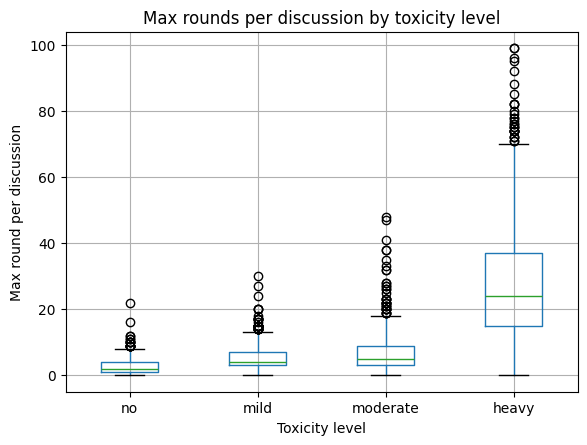

In [40]:
order = ["no", "mild", "moderate", "heavy"]
df_oss["toxicity_level"] = pd.Categorical(df_oss["toxicity_level"], categories=order, ordered=True)

df_oss.boxplot(column="max_round_per_discussion", by="toxicity_level")
plt.title("Max rounds per discussion by toxicity level")
plt.xlabel("Toxicity level")
plt.ylabel("Max round per discussion")
plt.suptitle("")  # removes the default pandas suptitle
plt.show()

In [45]:
import json

In [46]:
records = []
for full_path in directory.rglob("*.json"):
    with open(full_path, 'r') as fp:
        data = json.load(fp)

    records.append({
        "topic_nr": data["topic_nr"],
        "topic": data["proposition"],
        "round": data["nrounds"],
    })

In [47]:
dt_topics = pd.DataFrame(records).merge(dt_oss, on="round", how="right")

In [48]:
dt_topics.groupby("topic")["toxicity_level"].value_counts()

topic                                                  toxicity_level
Drunk driving should not be a crime itself.            no                32014
                                                       mild              23475
                                                       moderate          14398
                                                       heavy               808
Governments should prioritise spending money on youth  no                25166
                                                                         ...  
We should support international adoption               heavy               427
We should use force to protect human rights abroad     no                20502
                                                       mild              15548
                                                       moderate           9724
                                                       heavy               430
Name: count, Length: 256, dtype: int64

In [23]:
dt_oss.head(10)

,Path,discussion,round,toxicity_level,max_round_per_discussion,rounds_to_convergence,reason_for_convergence,which_agent_is_toxic,toxic_agent,pro_wins,con_wins,opening_agent,starting_agent,starter_wins,winning_agent
2,discussion_193_round_2_for_topic_63_neither_to...,193,2,no,2,8.0,pro has been convinced,con has toxic behaviour,1,0,1,pro,con,1,0
4,discussion_114_round_14_for_topic_36_pro_toxic...,114,14,mild,14,24.0,pro has been convinced,pro has toxic behaviour,0,0,1,con,con,1,0
5,discussion_564_round_2_for_topic_11_pro_toxic_...,564,2,mild,2,8.0,con has been convinced,pro has toxic behaviour,0,1,0,pro,pro,1,1
8,discussion_332_round_27_for_topic_1_con_toxic_...,332,27,heavy,27,20.0,pro has been convinced,con has toxic behaviour,1,0,1,pro,con,1,0
11,discussion_688_round_3_for_topic_34_con_toxic_...,688,3,mild,3,10.0,pro has been convinced,con has toxic behaviour,1,0,1,con,con,1,0
12,discussion_758_round_7_for_topic_46_con_toxic_...,758,7,moderate,7,12.0,con has been convinced,con has toxic behaviour,1,1,0,con,pro,1,1
13,discussion_174_round_2_for_topic_60_neither_to...,174,2,no,2,6.0,con has been convinced,pro has toxic behaviour,0,1,0,con,pro,1,1
14,discussion_5_round_44_for_topic_9_con_toxic_le...,5,44,heavy,44,24.0,con has been convinced,con has toxic behaviour,1,1,0,pro,pro,1,1
15,discussion_79_round_7_for_topic_49_pro_toxic_l...,79,7,moderate,7,16.0,con has been convinced,pro has toxic behaviour,0,1,0,con,pro,1,1
18,discussion_783_round_45_for_topic_52_pro_toxic...,783,45,heavy,45,25.0,con has been convinced,pro has toxic behaviour,0,1,0,con,con,0,1
